# Week4_ex1_to_2_analysis - Induction Heating Core: Stainless Steel vs Ferrite

![Week4_ex1 result](Images/Week4_ex1_result_image.png)

Rectangular core (200 x 150 mm, 40 mm thick legs) with a 5-turn square coil (100 A peak, 10 Hz) wound around one leg. A 40 mm-radius hole cuts that leg completely over z = -15 ~ 15 mm, and the calculation volume `Core_cal` (36-sided cylinder, r = 20 mm, h = 30 mm) sits in the gap, touching the core at its top and bottom faces. Week4_ex1 uses steel_stainless for the core, Week4_ex2 uses Ferrite; everything else in the two notebooks is identical.

The two cases need different kinds of checks. Stainless steel has mu_r = 1, so the "core" doesn't shape the field at all and the coil field can be computed exactly with Biot-Savart - this is a check with no anomaly, so it stays short. Ferrite (mu_r = 1000) turns the core into a magnetic circuit, which has no exact closed form here, so ex2 is only an order check.

$$\mathbf{B}(\mathbf{r})=\frac{\mu_0 I}{4\pi}\oint\frac{d\mathbf{l}\times(\mathbf{r}-\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|^3},\qquad P_{eddy}\approx\frac{\sigma\omega^2}{2}\int_{V}|A_\phi|^2\,dV\quad(\delta\gg r)$$

$$B_{cal}\approx\frac{NI}{A_{cal}\,\mathcal{R}},\qquad \mathcal{R}=\frac{l_{core}}{\mu_r\mu_0A_{leg}}+\frac{h}{\mu_r\mu_0A_{cal}}$$

## Week4_ex1 - Stainless steel core (mu_r = 1)

With mu_r = 1 the only source of B is the coil current. The skin depth of stainless steel at 10 Hz is about 150 mm, far larger than the 20 mm radius of `Core_cal`, so the eddy currents are too weak to push back on the field. That means the field inside `Core_cal` is just the free-space coil field, and the induced E is simply -j*omega*A.

The coil is rebuilt below from its centerline, exactly as the polyline points are defined in the original notebook (including the 100 mm lead-in/out wires and the 5 mm steps between turns), in a local frame centered on the leg axis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. FEM results exported by the original notebook (Core_cal: Integrate(Ohmic_Loss), Mean(Mag_B) at Phase = 0deg)
fem_ex1 = pd.read_csv("Week4_ex1_result.csv")
P_fem_ex1 = float(fem_ex1["core_ohmic_loss"][0])
B_fem_ex1 = float(fem_ex1["core_b_field"][0])

# 2. Model constants -- material values read once from the AEDT material library (steel_stainless)
mu0 = 4e-7 * np.pi
I = 100.0                     # winding current, peak magnitude [A]
f = 10.0
w = 2 * np.pi * f
sigma_ss = 1.1e6              # steel_stainless conductivity [S/m]
R_cal, h_cal, n_sides = 20e-3, 30e-3, 36

half = 23e-3                  # coil_len / 2 = (40 + 6) / 2 mm
gap = 5e-3
turns = 5
pts = [(half, -half - 100e-3, 0.0)]
for n in range(turns):
    z = n * gap
    pts += [(half, -half, z), (half, half, z), (-half, half, z), (-half, -half, z)]
pts.append((-half, -half - 100e-3, (turns - 1) * gap))
coil = np.array(pts) - np.array([0, 0, (turns - 1) * gap / 2])   # same z shift as coil.move()

print(f"skin depth at 10 Hz: {np.sqrt(2 / (w * mu0 * sigma_ss)) * 1e3:.0f} mm")

skin depth at 10 Hz: 152 mm


In [2]:
# 3. Biot-Savart B and Coulomb-gauge A of the straight-segment coil centerline
def coil_fields(r):
    B = np.zeros_like(r)
    A = np.zeros_like(r)
    for P1, P2 in zip(coil[:-1], coil[1:]):
        a = P2 - P1
        L = np.linalg.norm(a)
        r1, r2 = r - P1, r - P2
        n1, n2 = np.linalg.norm(r1, axis=1), np.linalg.norm(r2, axis=1)
        c = np.cross(a, r1)
        B += mu0 * I / (4 * np.pi) * c / np.sum(c**2, axis=1)[:, None] * ((r1 @ a) / n1 - (r2 @ a) / n2)[:, None]
        A += mu0 * I / (4 * np.pi) * (a / L)[None, :] * np.log((n1 + n2 + L) / (n1 + n2 - L))[:, None]
    return B, A

# 4. Midpoint-rule volume integration over the 36-sided Core_cal (circumradius 20 mm, first vertex on +x)
N, Nz = 100, 60
dx, dz = 2 * R_cal / N, h_cal / Nz
xs = -R_cal + dx * (np.arange(N) + 0.5)
zs = -h_cal / 2 + dz * (np.arange(Nz) + 0.5)
X, Y, Z = np.meshgrid(xs, xs, zs, indexing="ij")
p = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)
rho = np.hypot(p[:, 0], p[:, 1])
phi_local = np.mod(np.arctan2(p[:, 1], p[:, 0]), 2 * np.pi / n_sides) - np.pi / n_sides
p = p[rho * np.cos(phi_local) <= R_cal * np.cos(np.pi / n_sides)]

B, A = coil_fields(p)
rho = np.hypot(p[:, 0], p[:, 1])
A_phi = (-A[:, 0] * p[:, 1] + A[:, 1] * p[:, 0]) / rho
dV = dx * dx * dz
V = len(p) * dV

B_mean_bs = np.mean(np.linalg.norm(B, axis=1))
P_aphi = 0.5 * sigma_ss * w**2 * np.sum(A_phi**2) * dV
P_uniform = np.pi * sigma_ss * w**2 * B_fem_ex1**2 * R_cal**4 * h_cal / 16

pd.DataFrame({
    "quantity": ["Mean |B| in Core_cal [mT]", "Ohmic loss, uniform-B closed form [mW]", "Ohmic loss, Biot-Savart A_phi [mW]"],
    "theory": [B_mean_bs * 1e3, P_uniform * 1e3, P_aphi * 1e3],
    "FEM": [B_fem_ex1 * 1e3, P_fem_ex1 * 1e3, P_fem_ex1 * 1e3],
    "FEM vs theory [%]": [(B_fem_ex1 / B_mean_bs - 1) * 100, (P_fem_ex1 / P_uniform - 1) * 100, (P_fem_ex1 / P_aphi - 1) * 100],
}).round(4)

,quantity,theory,FEM,FEM vs theory [%]
0,Mean |B| in Core_cal [mT],11.2129,11.2139,0.0094
1,"Ohmic loss, uniform-B closed form [mW]",0.5147,0.4564,-11.3292
2,"Ohmic loss, Biot-Savart A_phi [mW]",0.4686,0.4564,-2.5998


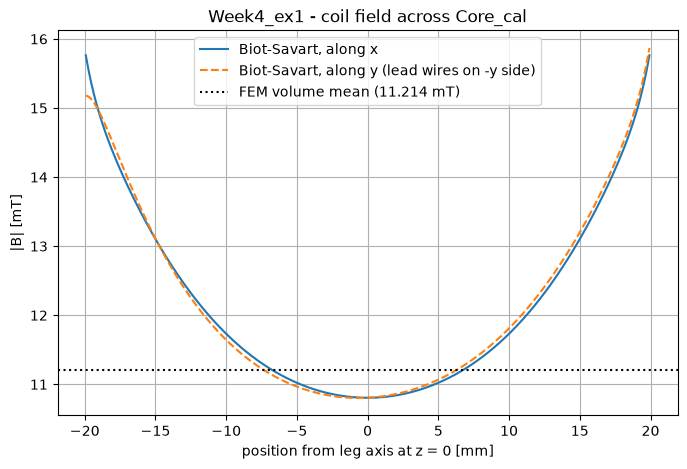

In [3]:
# 5. |B| across the Core_cal mid-plane (z = 0) along x and y, from Biot-Savart
s = np.linspace(-R_cal * np.cos(np.pi / n_sides), R_cal * np.cos(np.pi / n_sides), 201)
zero = np.zeros_like(s)
B_x, _ = coil_fields(np.stack([s, zero, zero], axis=1))
B_y, _ = coil_fields(np.stack([zero, s, zero], axis=1))

plt.figure(figsize=(8, 5))
plt.plot(s * 1e3, np.linalg.norm(B_x, axis=1) * 1e3, label="Biot-Savart, along x")
plt.plot(s * 1e3, np.linalg.norm(B_y, axis=1) * 1e3, "--", label="Biot-Savart, along y (lead wires on -y side)")
plt.axhline(B_fem_ex1 * 1e3, color="k", linestyle=":", label=f"FEM volume mean ({B_fem_ex1 * 1e3:.3f} mT)")
plt.xlabel("position from leg axis at z = 0 [mm]")
plt.ylabel("|B| [mT]")
plt.title("Week4_ex1 - coil field across Core_cal")
plt.grid(True)
plt.legend()
plt.savefig("Images/Week4_ex1_B_profile_in_core_cal.png", dpi=150, bbox_inches="tight")
plt.show()

The mean B matches Biot-Savart to +0.01%, which is what you'd expect when the core is magnetically invisible.

The loss is where the shape of the field matters. The closed form pi*sigma*omega^2*B^2*R^4*h/16 assumes a uniform axial B, but the field of a square coil this close to the cylinder is weakest on the axis and climbs about 45% toward the edge (plot above). The induced E at radius r is set by the flux enclosed inside r, and because the center is the weak part, the flux inside any inner circle is smaller than the mean B would suggest. So feeding the mean B into the uniform formula overestimates E everywhere except right at the edge, and the FEM loss looks 11% low against it. Using the actual Biot-Savart A_phi brings the gap down to -2.6%. That leftover is within what this estimate can claim: it keeps only the azimuthal part of A and ignores the surface charges that keep J from leaving the cylinder, so it isn't pushed further.

## Week4_ex2 - Ferrite core (mu_r = 1000)

![Week4_ex2 result](../Week4_ex2/Images/Week4_ex2_result_image.png)

Same geometry and excitation, only the core material changes to Ferrite (mu_r = 1000, sigma = 0.01 S/m, read once from the AEDT material library). Now the frame carries the flux and `Core_cal` closes the 30 mm gap in the leg, so the closed loop of core is a magnetic circuit. The problem is choosing a path length: a 40 mm-thick leg around a 120 x 70 mm window has a mean path of 540 mm but an inner-edge path of only 380 mm, and flux tends to crowd toward the inside corners. Both are evaluated as bounds.

The FEM values below come from the CSV exported by the Week4_ex2 notebook.

In [4]:
# 6. Ferrite FEM results (same export as above, from the Week4_ex2 project)
fem_ex2 = pd.read_csv("../Week4_ex2/Week4_ex2_result.csv")
P_fem_ex2 = float(fem_ex2["core_ohmic_loss"][0])
B_fem_ex2 = float(fem_ex2["core_b_field"][0])

# 7. Magnetic circuit bounds -- material values read once from the AEDT material library (Ferrite)
mu_r, sigma_fe = 1000, 0.01
NI = turns * I
A_leg = 40e-3 * 40e-3
A_cal = n_sides / (2 * np.pi) * np.sin(2 * np.pi / n_sides) * np.pi * R_cal**2

def B_circuit(l_total):
    R = ((l_total - h_cal) / A_leg + h_cal / A_cal) / (mu_r * mu0)
    return NI / R / A_cal

l_eff = (NI * mu_r * mu0 / (B_fem_ex2 * A_cal) - h_cal / A_cal) * A_leg + h_cal

pd.DataFrame({
    "case": ["mean path (540 mm)", "inner-edge path (380 mm)", "FEM", "path length that reproduces FEM"],
    "B in Core_cal [T]": [B_circuit(0.540), B_circuit(0.380), B_fem_ex2, B_fem_ex2],
    "path length [mm]": [540, 380, np.nan, l_eff * 1e3],
}).round(3)

,case,B in Core_cal [T],path length [mm]
0,mean path (540 mm),1.466,540.000
1,inner-edge path (380 mm),2.070,380.000
2,FEM,1.786,NaN
3,path length that reproduces FEM,1.786,441.751


In [5]:
# 8. ex1 vs ex2 side by side, plus the eddy loss ferrite would have with the uniform-B closed form
P_uniform_fe = np.pi * sigma_fe * w**2 * B_fem_ex2**2 * R_cal**4 * h_cal / 16

pd.DataFrame({
    "core": ["steel_stainless", "Ferrite"],
    "mu_r": [1, mu_r],
    "sigma [S/m]": [sigma_ss, sigma_fe],
    "FEM mean |B| [T]": [B_fem_ex1, B_fem_ex2],
    "FEM ohmic loss [W]": [P_fem_ex1, P_fem_ex2],
    "uniform-B loss estimate [W]": [P_uniform, P_uniform_fe],
})

,core,mu_r,sigma [S/m],FEM mean |B| [T],FEM ohmic loss [W],uniform-B loss estimate [W]
0,steel_stainless,1,1100000.00,0.011214,0.000456,5.146809e-04
1,Ferrite,1000,0.01,1.786270,0.000000,1.187204e-07


## Conclusion

**Week4_ex1.** With a mu_r = 1 core the FEM field is just the coil's own field: the mean |B| in `Core_cal` agrees with Biot-Savart to +0.01%. The ohmic loss looks 11% low against the textbook uniform-field formula, but that gap comes from the formula, not the solver - the coil field is weakest on the axis, so the flux enclosed at inner radii (which sets the induced E) is lower than a uniform mean B implies. Integrating the real A_phi leaves a -2.6% difference, which is inside the accuracy of that estimate. Nothing here needs a hypothesis.

**Week4_ex2.** Swapping in ferrite raises the mean B in `Core_cal` from 11.2 mT to 1.79 T, about 160 times. The magnetic-circuit estimate brackets it between 1.47 T (mean path) and 2.07 T (inner-edge path), and the FEM corresponds to an effective path of about 440 mm - closer to the inside, which fits flux taking the shorter route around thick-legged corners. Two caveats: the EddyCurrent solver treats mu_r as linear, so 1.79 T is far beyond where a real ferrite would saturate (roughly 0.4 T); and the ohmic loss comes out as exactly 0, against a uniform-field estimate of about 1e-7 W with sigma = 0.01 S/m. Either way the loss is negligible, so I didn't chase why the export shows an exact zero. This stays an order check and needs no further analysis.